LIBRERÍAS

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

CREAR DATASET

In [3]:
np.random.seed(42)

data = pd.DataFrame({
    "estres": np.random.randint(1, 10, 200),
    "sueño": np.random.randint(3, 10, 200),
    "notas": np.random.randint(50, 100, 200),
    "motivacion": np.random.randint(1, 10, 200),
    "ansiedad": np.random.randint(1, 10, 200)
})

data["riesgo"] = (
    (data["estres"] > 6) |
    (data["ansiedad"] > 6) |
    (data["sueño"] < 5)
).astype(int)

data.head()

,estres,sueño,notas,motivacion,ansiedad,riesgo
0,7,3,53,9,2,1
1,4,5,55,1,1,0
2,8,6,94,6,9,1
3,5,3,81,7,9,1
4,7,3,79,8,9,1


DIVIDIR DATOS

In [4]:
X = data.drop("riesgo", axis=1)
y = data["riesgo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ESCALAR

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ENTRENAR MODELO

In [6]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

PREDICCIÓN

In [7]:
y_pred = model.predict(X_test)

RESULTADOS

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        10
           1       0.86      0.83      0.85        30

    accuracy                           0.78        40
   macro avg       0.70      0.72      0.71        40
weighted avg       0.78      0.78      0.78        40



PRUEBA REAL (DEMO)

In [10]:
nuevo = pd.DataFrame({
    "estres": [8],
    "sueño": [4],
    "notas": [60],
    "motivacion": [7],
    "ansiedad": [8]
})

pred = model.predict(scaler.transform(nuevo))

if pred[0] == 1:
    print("ALTO RIESGO DE SALUD MENTAL")
else:
    print("BAJO RIESGO")

ALTO RIESGO DE SALUD MENTAL


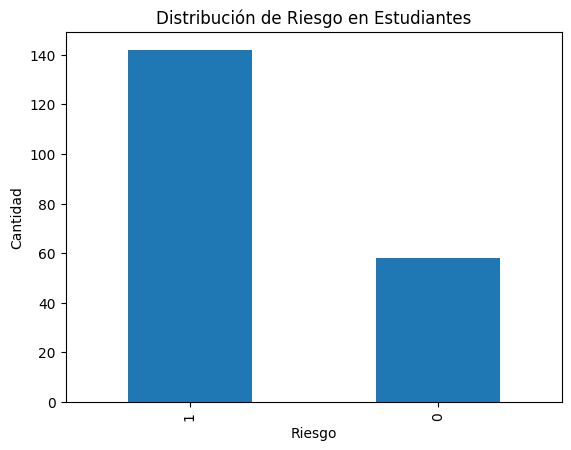

In [11]:
import matplotlib.pyplot as plt

data["riesgo"].value_counts().plot(kind="bar")

plt.title("Distribución de Riesgo en Estudiantes")
plt.xlabel("Riesgo")
plt.ylabel("Cantidad")
plt.show()